# CIFAR10 with CNNs
Simple starter notebook to benchmark your own CNN with PyTorch on the CIFAR-10 dataset.

OBS.:

- The main code is basically done, so focus on training the models and searching for the best hyperparameters and architectures.
- You are not required to use this exact code or even the PyTorch library.
- It is recommended to use execution environments with GPU access (such as Google Colab), since larger models will take more time to train.
- Remember to document the history of your experiments and which results motivated the changes in subsequent experiments.

In [5]:
# Montar o Drive (força a reconexão se necessário)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Preparação do Ambiente e Bibliotecas

In [6]:
pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00


In [7]:
#@title Libs

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold, train_test_split
from torch.utils.data import DataLoader, Subset

# Configuração dinâmica do dispositivo (GPU se disponível, senão CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


Definimos as transformações necessárias para as imagens do dataset, convertendo elas para tensores e normalizando. Em seguida, realizamos o download e carregamento dos conjuntos de dados de treino (50.000 imagens) e teste (10.000 imagens).

In [8]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Apontando o diretório raiz (root) direto para o Google Drive
caminho_dados_drive = '/content/drive/MyDrive/cifar10_projeto/data'

train_dataset = torchvision.datasets.CIFAR10(root=caminho_dados_drive, train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root=caminho_dados_drive, train=False,
                                       download=True, transform=transform)

100%|██████████| 170M/170M [00:06<00:00, 24.9MB/s]


Para otimizar o tempo de execução da busca de hiperparâmetros com o Optuna, criamos um subconjunto estratificado de 10.000 imagens a partir do dataset de treino original. A estratificação garante que o subconjunto mantenha a mesma proporção de classes (1.000 por categoria).


In [9]:
subset_size = 10000 # subconjunto pra ir mais rápido

train_indices = list(range(len(train_dataset)))
train_labels = [train_dataset[i][1] for i in train_indices]

search_indices, _ = train_test_split(
    train_indices,
    train_size=subset_size,
    stratify=train_labels, # garante a mesma quantidade por classe
    random_state=42
)

search_dataset = Subset(train_dataset, search_indices) # só no optuna

print(f"subconjunto de busca criado com {len(search_dataset)} imagens.")
print(f"representa {len(search_dataset)//10} imagens por classe.")

subconjunto de busca criado com 10000 imagens.
representa 1000 imagens por classe.


In [10]:
class CNN(nn.Module):
    def __init__(self, conv_filters, kernel_size, conv_stride, conv_pad, pool_size, fc_size, dropout_rate, activation_func):
        super(CNN, self).__init__()
        self.activation = activation_func

        # Agrupamento das camadas convolucionais
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=conv_filters[0], kernel_size=kernel_size, stride=conv_stride, padding=conv_pad),
            nn.BatchNorm2d(conv_filters[0]),
            activation_func,
            nn.MaxPool2d(kernel_size=pool_size, stride=pool_size),

            nn.Conv2d(in_channels=conv_filters[0], out_channels=conv_filters[1], kernel_size=kernel_size, stride=1, padding=conv_pad),
            nn.BatchNorm2d(conv_filters[1]),
            activation_func,
            nn.MaxPool2d(kernel_size=pool_size, stride=pool_size),

            nn.Conv2d(in_channels=conv_filters[1], out_channels=conv_filters[2], kernel_size=kernel_size, stride=1, padding=conv_pad),
            nn.BatchNorm2d(conv_filters[2]),
            activation_func,
            nn.MaxPool2d(kernel_size=pool_size, stride=pool_size)
        )

        # Passamos 2 imagens falsas (batch_size=2) para descobrir o tamanho final achatado e evitar erros no BatchNorm
        with torch.no_grad():
            dummy_input = torch.zeros(2, 3, 32, 32)
            dummy_output = self.features(dummy_input)
            flattened_size = dummy_output.view(2, -1).size(1)

        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(flattened_size, fc_size)
        self.fc2 = nn.Linear(fc_size, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.activation(self.fc1(x)))
        x = self.fc2(x)
        return x

### Espaço de Busca e Arquiteturas (CNN)
Para investigar o impacto da arquitetura da rede, definimos algumas combinações de filtros para os blocos convolucionais:

- Pequena: (32, 64, 128) filtros.
- Media: (64, 128, 256) filtros para capturar mais padrões intermediários.
- Crescente: Uma rede que cresce drasticamente em filtros (32, 128, 512).

Além da arquitetura, o Optuna varia dinamicamente a Taxa de Aprendizado (lr), o Dropout, o Weight Decay (L2), o tamanho do Filtro Convolucional (Kernel Size), funções de ativação e o Batch Size.

In [11]:
def objective_cnn(trial):
    conv_arch_dict = {
        "Super_Pequena": (16, 32, 64),
        "Pequena": (32, 64, 128),
        "Media": (64, 128, 256),
        "Grande": (128, 256, 512),
        "Crescente": (32, 128, 512),
    }

    arch_name = trial.suggest_categorical("conv_arch", list(conv_arch_dict.keys()))
    conv_filters = conv_arch_dict[arch_name]

    kernel_size = trial.suggest_categorical("kernel_size", [3, 5])
    conv_stride = trial.suggest_categorical("stride", [1, 2])
    conv_pad = trial.suggest_categorical("padding", [0, 1, 2])
    pool_size = trial.suggest_categorical("pool_size", [2, 3])
    fc_size = trial.suggest_categorical("fc_size", [64, 128, 256, 512])

    dropout_rate = trial.suggest_float("dropout", 0.0, 0.6)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    activation_name = trial.suggest_categorical("activation", ["ReLU", "Tanh", "LeakyReLU", "ELU"])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    activations = {
        "ReLU": nn.ReLU(), "Tanh": nn.Tanh(), "LeakyReLU": nn.LeakyReLU(), "ELU": nn.ELU()
    }

    print(f"\nIniciando Trial CNN #{trial.number}")
    print(f"Arch: {arch_name} {conv_filters} | Kernel: {kernel_size} | Stride: {conv_stride} | Pad: {conv_pad} | Pool: {pool_size}")

    k_folds = 3
    kfold = KFold(n_splits=k_folds, shuffle=True)
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(search_dataset)):
        train_sub = Subset(search_dataset, train_ids)
        val_sub = Subset(search_dataset, val_ids)

        # O drop_last=True evita erros no BatchNorm caso sobre 1 imagem isolada no final do lote
        t_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True, drop_last=True)
        v_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False, drop_last=True)

        try:
            model = CNN(conv_filters, kernel_size, conv_stride, conv_pad, pool_size, fc_size, dropout_rate, activations[activation_name]).to(device)
            _ = model(next(iter(t_loader))[0].to(device)) # Teste rápido para validar dimensões
        except (RuntimeError, ValueError):
            print(f"  > Fold {fold+1}: Combinação inválida de filtros/stride. Ignorando trial...")
            return 0.0

        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)

        for epoch in range(5):
            model.train()
            for images, labels in t_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(model(images), labels)
                loss.backward()
                optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in v_loader:
                images, labels = images.to(device), labels.to(device)
                pred = model(images).argmax(dim=1)
                correct += pred.eq(labels).sum().item()

        # Calcula-se a acurácia com base no tamanho do v_loader devido ao drop_last
        acc = correct / (len(v_loader) * batch_size)
        fold_accuracies.append(acc)

    mean_accuracy = np.mean(fold_accuracies)
    print(f"RESULTADO TRIAL CNN #{trial.number}: Acurácia Média (CV) = {mean_accuracy:.4f}")

    return mean_accuracy

In [12]:
study_cnn = optuna.create_study(direction="maximize")
study_cnn.optimize(objective_cnn, n_trials=100)

print(f"\nMelhor Acurácia de Validação CNN: {study_cnn.best_value:.4f}")
print(f"Melhores Parâmetros CNN: {study_cnn.best_params}")

df_results = study_cnn.trials_dataframe()
df_results.to_csv("experimentos_cnn_optuna.csv", index=False)

[I 2026-03-28 20:46:17,521] A new study created in memory with name: no-name-4a6665e6-801b-4bfb-a910-f7b2bacf98f9



Iniciando Trial CNN #0
Arch: Grande (128, 256, 512) | Kernel: 3 | Stride: 1 | Pad: 1 | Pool: 2


[I 2026-03-28 20:46:54,153] Trial 0 finished with value: 0.37940705128205127 and parameters: {'conv_arch': 'Grande', 'kernel_size': 3, 'stride': 1, 'padding': 1, 'pool_size': 2, 'fc_size': 128, 'dropout': 0.3344692656897866, 'lr': 0.00028117366485180204, 'weight_decay': 5.134358730341826e-05, 'activation': 'Tanh', 'optimizer': 'SGD', 'batch_size': 32}. Best is trial 0 with value: 0.37940705128205127.


RESULTADO TRIAL CNN #0: Acurácia Média (CV) = 0.3794

Iniciando Trial CNN #1
Arch: Media (64, 128, 256) | Kernel: 5 | Stride: 1 | Pad: 1 | Pool: 2


[I 2026-03-28 20:47:21,492] Trial 1 finished with value: 0.43008814102564097 and parameters: {'conv_arch': 'Media', 'kernel_size': 5, 'stride': 1, 'padding': 1, 'pool_size': 2, 'fc_size': 64, 'dropout': 0.342498953969866, 'lr': 1.1212281526301373e-05, 'weight_decay': 0.0004893938694192341, 'activation': 'ELU', 'optimizer': 'AdamW', 'batch_size': 128}. Best is trial 1 with value: 0.43008814102564097.
[I 2026-03-28 20:47:21,562] Trial 2 finished with value: 0.0 and parameters: {'conv_arch': 'Super_Pequena', 'kernel_size': 5, 'stride': 2, 'padding': 1, 'pool_size': 2, 'fc_size': 512, 'dropout': 0.3923775517908296, 'lr': 0.006612146160149941, 'weight_decay': 3.43028474242574e-05, 'activation': 'LeakyReLU', 'optimizer': 'Adam', 'batch_size': 128}. Best is trial 1 with value: 0.43008814102564097.


...

RESULTADO TRIAL CNN #97: Acurácia Média (CV) = 0.6144

Iniciando Trial CNN #98
Arch: Pequena (32, 64, 128) | Kernel: 5 | Stride: 1 | Pad: 1 | Pool: 2


[I 2026-03-28 21:31:34,459] Trial 98 finished with value: 0.21975160256410256 and parameters: {'conv_arch': 'Pequena', 'kernel_size': 5, 'stride': 1, 'padding': 1, 'pool_size': 2, 'fc_size': 512, 'dropout': 0.3816217578329801, 'lr': 0.0002048533097071148, 'weight_decay': 0.0031774976375354294, 'activation': 'LeakyReLU', 'optimizer': 'SGD', 'batch_size': 64}. Best is trial 81 with value: 0.6229967948717948.


RESULTADO TRIAL CNN #98: Acurácia Média (CV) = 0.2198

Iniciando Trial CNN #99
Arch: Media (64, 128, 256) | Kernel: 3 | Stride: 1 | Pad: 2 | Pool: 2


[I 2026-03-28 21:32:04,456] Trial 99 finished with value: 0.6100761217948718 and parameters: {'conv_arch': 'Media', 'kernel_size': 3, 'stride': 1, 'padding': 2, 'pool_size': 2, 'fc_size': 512, 'dropout': 0.4059395749810594, 'lr': 0.00022220966686045486, 'weight_decay': 0.0014247931538747198, 'activation': 'LeakyReLU', 'optimizer': 'AdamW', 'batch_size': 64}. Best is trial 81 with value: 0.6229967948717948.


RESULTADO TRIAL CNN #99: Acurácia Média (CV) = 0.6101

Melhor Acurácia de Validação CNN: 0.6230
Melhores Parâmetros CNN: {'conv_arch': 'Media', 'kernel_size': 3, 'stride': 1, 'padding': 1, 'pool_size': 2, 'fc_size': 512, 'dropout': 0.5283639085935068, 'lr': 0.0004858907885204893, 'weight_decay': 0.003993803777734024, 'activation': 'LeakyReLU', 'optimizer': 'AdamW', 'batch_size': 64}


In [13]:
import optuna.visualization as vis

vis.plot_param_importances(study_cnn).show()
vis.plot_optimization_history(study_cnn).show()
vis.plot_parallel_coordinate(study_cnn).show()

In [15]:
import os
os.makedirs('/content/drive/MyDrive/cifar10_projeto/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/cifar10_projeto/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/cifar10_projeto/metrics', exist_ok=True)
print("Pastas criadas com sucesso no novo Drive!")

Pastas criadas com sucesso no novo Drive!


In [16]:
best_params = study_cnn.best_params

conv_arch_dict = {"Super_Pequena": (16, 32, 64), "Pequena": (32, 64, 128), "Media": (64, 128, 256), "Crescente": (32, 128, 512), "Cilindro": (128, 128, 128)}
activations = {"ReLU": nn.ReLU(), "Tanh": nn.Tanh(), "LeakyReLU": nn.LeakyReLU(), "ELU": nn.ELU()}

best_conv_filters = conv_arch_dict[best_params["conv_arch"]]
best_activation = activations[best_params["activation"]]

print(f"\nTreinando o modelo CNN final com os melhores parâmetros...")

best_cnn_model = CNN(
    conv_filters=best_conv_filters,
    kernel_size=best_params["kernel_size"],
    conv_stride=best_params["stride"],
    conv_pad=best_params["padding"],
    pool_size=best_params["pool_size"],
    fc_size=best_params["fc_size"],
    dropout_rate=best_params["dropout"],
    activation_func=best_activation
).to(device)

optimizer = getattr(torch.optim, best_params["optimizer"])(
    best_cnn_model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"]
)

full_train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True, drop_last=True)

best_loss = float('inf')
patience = 5
patience_counter = 0
max_epochs = 50
best_model_path = '/content/drive/MyDrive/cifar10_projeto/models/melhor_modelo_cnn_final.pth'

for epoch in range(max_epochs):
    best_cnn_model.train()
    epoch_loss = 0.0

    for images, labels in tqdm(full_train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = nn.CrossEntropyLoss()(best_cnn_model(images), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(full_train_loader)
    print(f"Época {epoch+1} finalizada. Loss Média: {avg_epoch_loss:.4f}")

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(best_cnn_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly Stopping ativado na época {epoch+1}.")
            break


Treinando o modelo CNN final com os melhores parâmetros...


Época 1 finalizada. Loss Média: 1.3274


Época 2 finalizada. Loss Média: 0.9583


Época 3 finalizada. Loss Média: 0.8216


Época 4 finalizada. Loss Média: 0.7344


...

Época 46 finalizada. Loss Média: 0.0383


Época 47 finalizada. Loss Média: 0.0397


Época 48 finalizada. Loss Média: 0.0310


Época 49 finalizada. Loss Média: 0.0298


Época 50 finalizada. Loss Média: 0.0314



--- Resultados Finais no Conjunto de Teste ---
Acurácia Geral: 0.8224
Precisão (Weighted): 0.8224
Recall (Weighted): 0.8224
F1-Score (Weighted): 0.8206

Relatório por Classe:
              precision    recall  f1-score   support

    airplane       0.87      0.82      0.85      1000
  automobile       0.92      0.91      0.92      1000
        bird       0.79      0.68      0.73      1000
         cat       0.70      0.67      0.68      1000
        deer       0.83      0.74      0.79      1000
         dog       0.75      0.74      0.75      1000
        frog       0.76      0.94      0.84      1000
       horse       0.85      0.88      0.86      1000
        ship       0.88      0.93      0.90      1000
       truck       0.86      0.91      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



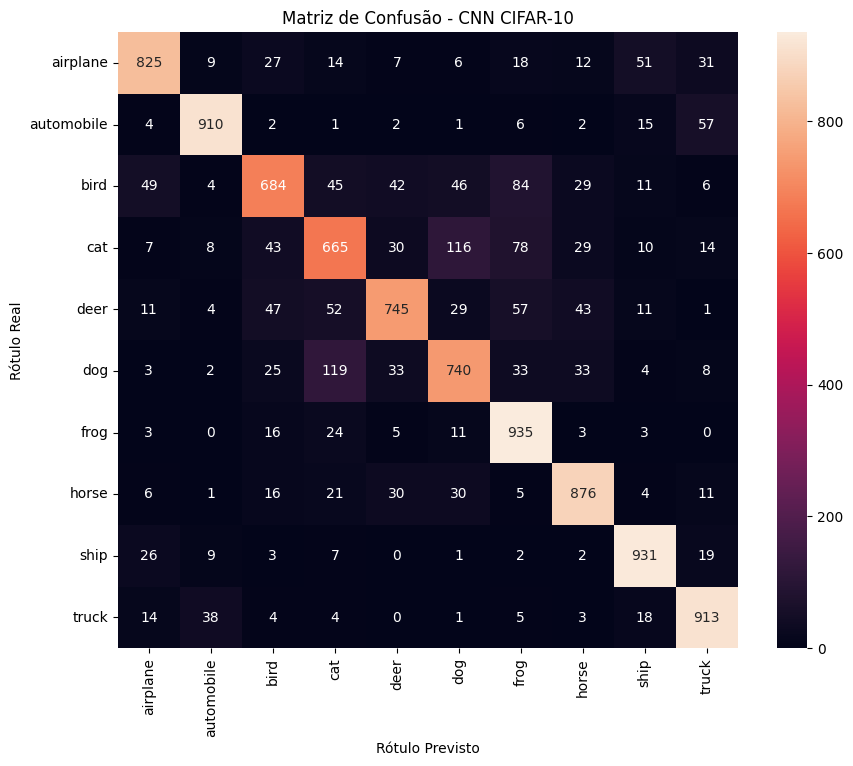

In [17]:
best_cnn_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_cnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in DataLoader(test_dataset, batch_size=64, shuffle=False):
        images = images.to(device)
        all_preds.extend(best_cnn_model(images).argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\n--- Resultados Finais no Conjunto de Teste ---")
print(f"Acurácia Geral: {accuracy:.4f}")
print(f"Precisão (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}\n")

print("Relatório por Classe:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.title('Matriz de Confusão - CNN CIFAR-10')
plt.show()